# Chemical map generation

This notebook demonstrates the process of generating chemical maps from hyperspectral images using traditional pixel-wise analysis and geostatistical validation. It covers loading and visualizing hyperspectral data, segmenting objects of interest (kiwi fruit), applying a pre-trained PLS regression model to predict chemical properties, and evaluating the spatial structure and noise in the resulting chemical maps.

## Loading spectra

We will start by loading a hyperspectral image and creating a pseudo-RGB image for segmentation and illustrating purposes.

In [14]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

filepath = "data/1A.mat"
mat = scipy.io.loadmat(filepath)


hyperspectral_img = mat["img"]
wavelengths = mat["Wavelength"]

In [15]:
red = 575
green = 535
blue = 445

def find_closest_index(target, array):
    array = np.asarray(array)
    idx = np.abs(array - target).argmin()
    return idx

def create_pseudo_rgb_image(hyperspectral_image, wavelengths):
    r_index = find_closest_index(red,wavelengths)
    g_index = find_closest_index(green,wavelengths)
    b_index = find_closest_index(blue,wavelengths)
    rgb_img = np.stack([
        hyperspectral_image[:, :, r_index],
        hyperspectral_image[:, :, g_index],
        hyperspectral_image[:, :, b_index]
    ], axis=-1)

    norm_img = np.empty_like(rgb_img, dtype=np.float32)

    # Normalize each channel independently
    for i in range(3):
        channel = rgb_img[:, :, i]
        vmin = np.percentile(channel, 1)
        vmax = np.percentile(channel, 99)
        norm_img[:, :, i] = np.clip((channel - vmin) / (vmax - vmin), 0, 1)

    # Convert to uint8
    rgb_uint8 = (norm_img * 255).astype(np.uint8)
    return rgb_uint8

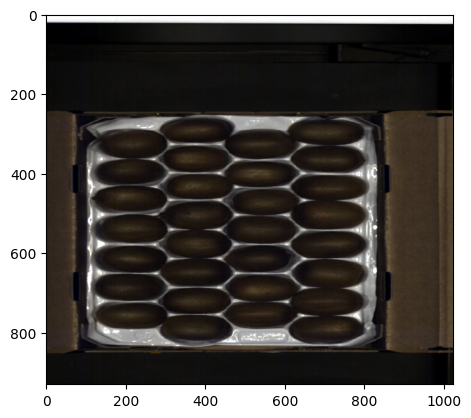

In [16]:
rgb_img = create_pseudo_rgb_image(hyperspectral_img, wavelengths)
fig = plt.figure()
plt.imshow(rgb_img)

## Segmenting the image

Similar to the previous labs we will start by segmentating the pseudo-RGB image and selecting the masks belonging to the kiwi fruit.

In [17]:
import torch
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator
import supervision as sv

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"DEVICE = {DEVICE}")

MODEL_TYPE = "vit_h"
SAM_SAM_CHECKPOINT_PATH = "weights/sam_vit_h_4b8939.pth"

sam = sam_model_registry[MODEL_TYPE](checkpoint=SAM_SAM_CHECKPOINT_PATH).to(device=DEVICE)
mask_generator = SamAutomaticMaskGenerator(sam)
sam_result = mask_generator.generate(rgb_img)
sam_detections = sv.Detections.from_sam(sam_result=sam_result)

DEVICE = cuda:0


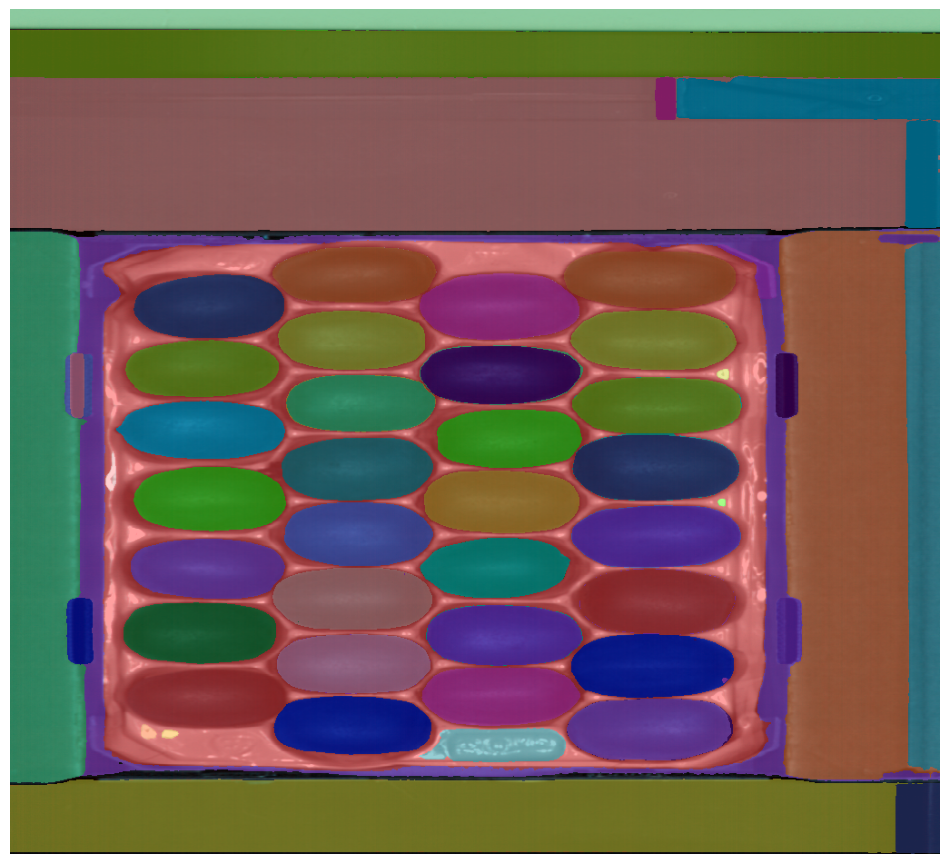

In [18]:
mask_annotator = sv.MaskAnnotator(color_lookup = sv.ColorLookup.INDEX)
sam_result = mask_annotator.annotate(scene=rgb_img.copy(), detections=sam_detections)
sv.plot_image(image=sam_result)

We first filter the masks by their size (in pixels)

In [19]:
min_height = 40
max_height = 100
min_width = 150
max_width = 200

def make_sv_detections(masks, xyxy):
    return sv.Detections(xyxy=np.array(xyxy), mask=np.stack(masks))

def filter_masks_by_size(detections):
    filtered_masks = []
    filtered_xyxy = []
    for detection in detections:
        mask = detection[1]
        xyxy = detection[0]
        y_coords, x_coords = np.where(mask)
        height = y_coords.max() - y_coords.min() + 1
        width = x_coords.max() - x_coords.min() + 1

        if min_height <= height <= max_height and min_width <= width <= max_width:
            filtered_masks.append(mask)
            filtered_xyxy.append(xyxy) 
    return make_sv_detections(filtered_masks, filtered_xyxy)

filtered_detections = filter_masks_by_size(sam_detections)

Then we make sure we do not have overlapping masks

In [20]:
def remove_overlapping_masks(detections):
    occupied = np.zeros_like(detections.mask[0], dtype=bool)
    non_overlapping_masks = []
    non_overlapping_xyxy = []

    for mask, box in zip(detections.mask, detections.xyxy):
        if not np.any(mask & occupied):
            non_overlapping_masks.append(mask)
            non_overlapping_xyxy.append(box)
            occupied |= mask  # Mark this area as taken

    if not non_overlapping_masks:
        return sv.Detections(xyxy=np.empty((0, 4)), mask=np.empty((0, *detections.mask[0].shape), dtype=bool))

    filtered_xyxy = np.array(non_overlapping_xyxy)
    filtered_masks = np.stack(non_overlapping_masks)

    return sv.Detections(xyxy=filtered_xyxy, mask=filtered_masks)


filtered_detections = remove_overlapping_masks(filtered_detections)

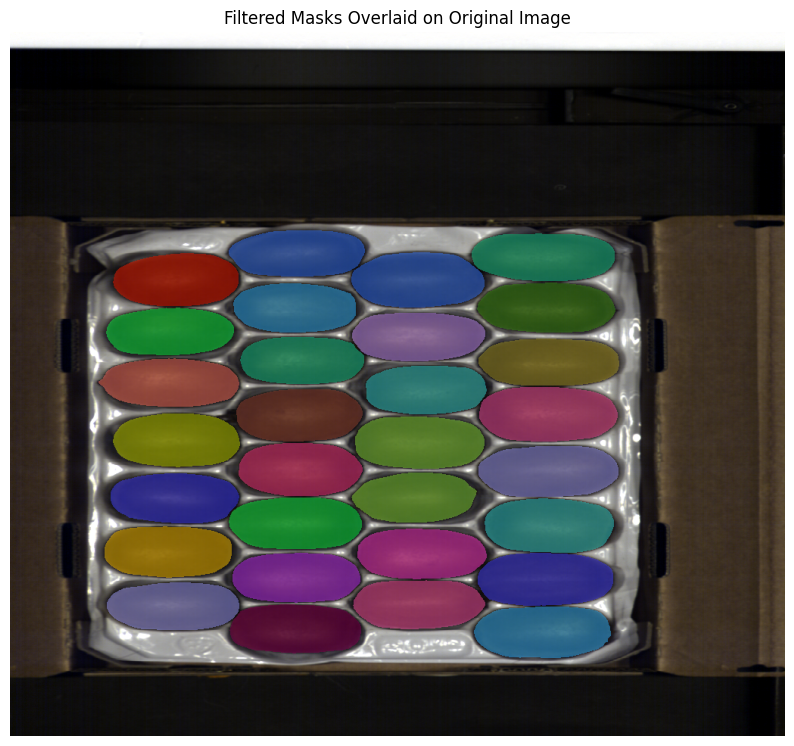

In [21]:
# Create the annotated image
annotated_img = mask_annotator.annotate(scene=rgb_img.copy(), detections=filtered_detections)

# Plot the original image with overlaid masks
plt.figure(figsize=(10, 10))
plt.imshow(annotated_img)
plt.axis("off")
plt.title("Filtered Masks Overlaid on Original Image")
plt.show()

As the last step we will sort the kiwis in order from left to right, from top to bottom. This step is optional, for the purpose of the lab it doesn't matter which kiwi and its segmentation mask we choose. 

In [22]:
from sklearn.cluster import DBSCAN

def compute_centroids(detections):
    centroids = []
    for mask in detections.mask:
        y_coords, x_coords = np.where(mask)
        cx = np.mean(x_coords)
        cy = np.mean(y_coords)
        centroids.append((cx, cy))
    return np.array(centroids)

# Compute centroids
centroids = compute_centroids(filtered_detections)

# Cluster by x-coordinate only (to group into columns)
clustering = DBSCAN(eps=50, min_samples=1).fit(centroids[:, [0]])
labels = clustering.labels_

# Group centroids and masks by cluster
clustered = {}
for label, centroid, mask, xyxy in zip(labels, centroids, filtered_detections.mask, filtered_detections.xyxy):
    clustered.setdefault(label, []).append((centroid, mask, xyxy))

# Sort columns from right to left
sorted_columns = sorted(
    clustered.items(), 
    key=lambda item: -np.mean([entry[0][0] for entry in item[1]])  # entry[0][0] is centroid's x coordinate
)

# For each column, sort top to bottom
sorted_detections = []
for _, column in sorted_columns:
    sorted_column = sorted(column, key=lambda entry: entry[0][1])  # sort by y of centroid
    sorted_detections.extend(sorted_column)  # each entry: (centroid, mask, xyxy)

## PLS Regression

To create a chemical map we will use the PLS regression model we have trained in the lab "Spectral analysis". 

In [23]:
import joblib

plsr = joblib.load('results/plsr_model.pkl')

## Chemical map generation

First of all, we will choose one kiwi detection and crop the "RGB" image around it with some margin.

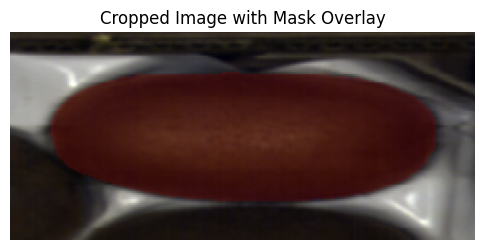

In [24]:
import numpy as np

# Choose the detection you're interested in (e.g., the first one)
chosen_idx = 0
_, mask, xyxy = sorted_detections[chosen_idx]
x_min, y_min, x_max, y_max = xyxy

# Add margin (e.g., 20 pixels)
margin = 20
y_min = max(0, y_min - margin)
y_max = min(rgb_img.shape[0], y_max + margin)
x_min = max(0, x_min - margin)
x_max = min(rgb_img.shape[1], x_max + margin)

# Crop the original image
cropped_img = rgb_img[y_min:y_max, x_min:x_max]

# Crop the mask just like the image
cropped_mask = mask[y_min:y_max, x_min:x_max]

# Create an RGB version of the cropped image
cropped_img_rgb = cropped_img.copy()

# Overlay: for example, make masked areas reddish
overlay = cropped_img_rgb.copy()
overlay[cropped_mask] = [255, 0, 0]  # Red color

# Blend original and overlay
alpha = 0.15  # Transparency
blended = (cropped_img_rgb * (1 - alpha) + overlay * alpha).astype(np.uint8)

# Plot
plt.figure(figsize=(6, 6))
plt.imshow(blended)
plt.title("Cropped Image with Mask Overlay")
plt.axis("off")
plt.show()

We repeat the same step for the hyperspectral image and we flatten it. This step is necessary since the input shape of our model takes one spectrum at a time to make a prediction.

In [33]:
X_mask = hyperspectral_img[y_min:y_max, x_min:x_max, :]
height, width, bands = X_mask.shape
X_mask_reshaped = X_mask.reshape(-1, X_mask.shape[2])

In [34]:
X_mask_reshaped.shape

(23256, 224)

We have to apply the same pre-processing steps as the data we trained our calibration model on.

In [27]:
import nippy

preprocessing_pipeline = {'MSC': None, 
                          'SAVGOL': 
                          {'deriv_order': 2, 
                           'filter_win': 13, 
                           'poly_order': 2}, 
                           'SNV': {}}

wl, X_mask_reshaped_processed = nippy.run_pipeline(wavelengths, X_mask_reshaped.T, preprocessing_pipeline)
X_mask_reshaped_processed = X_mask_reshaped_processed.T

Now  we're finally ready to apply our calibration model to one kiwi to create a chemical map.

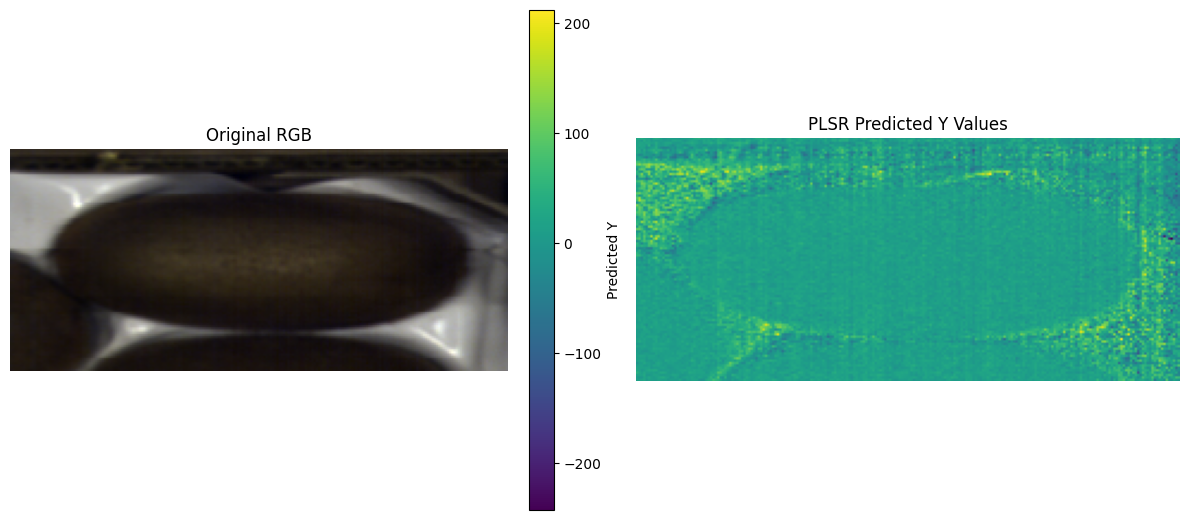

In [35]:
import matplotlib.cm as cm

y_mask = plsr.predict(X_mask_reshaped_processed)
y_mask_restored_shape = y_mask.reshape((height, width))

# Set color range based on actual values
vmin = np.min(y_mask_restored_shape) 
vmax = np.max(y_mask_restored_shape)

# Create figure with two subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# --- Plot 1: Original RGB image ---
axs[0].imshow(cropped_img_rgb)
axs[0].set_title("Original RGB")
axs[0].axis("off")

# --- Plot 2: PLSR heatmap with colorbar ---
im = axs[1].imshow(y_mask_restored_shape, cmap='viridis', vmin=vmin, vmax=vmax)
axs[1].set_title("PLSR Predicted Y Values")
axs[1].axis("off")

# Add colorbar to the first subplot
cbar = plt.colorbar(im, ax=axs[0], fraction=0.046, pad=0.04)
cbar.set_label("Predicted Y")

plt.tight_layout()
plt.show()

If we're only interested in the chemical map of the object we can apply the mask to the predicted values.

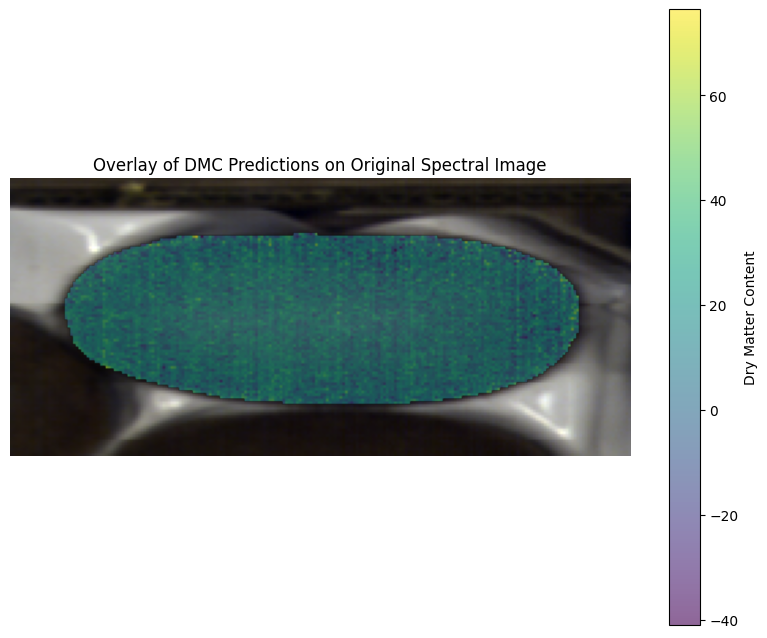

In [29]:
masked_pred = np.where(cropped_mask == 1, y_mask_restored_shape, np.nan)

plt.figure(figsize=(10, 8))

# Show original image in grayscale or RGB
plt.imshow(cropped_img_rgb, cmap='gray', alpha=1.0)  # adjust cmap if RGB

# Overlay masked predictions with a colormap and transparency
plt.imshow(masked_pred, cmap='viridis', alpha=0.6)  # alpha controls transparency

plt.colorbar(label='Dry Matter Content')
plt.title("Overlay of DMC Predictions on Original Spectral Image")
plt.axis('off')
plt.show()

In [30]:
average_dry_matter = np.mean(y_mask_restored_shape[cropped_mask==1])
print(average_dry_matter)

14.934101695311604


## Validation of chemical maps

By applying geostatistical analysis to the predicted dry matter maps, we can better understand how dry matter varies spatially across fruit surfaces and how much of this variation is structured (systematic) versus unstructured (random).

We use a series of metrics:

- Nugget effect (c₀): Captures small-scale randomness or noise in predictions
- Sill (total variance): Overall variability of dry mtter across the fruit
- Partial sill (s₁): Spatially structured component of the variability
- SPD Index: Percentage of variance that is spatially structured
- Cambardella Index: Percentage of variance due to noise/randomness
- Signal-to-noise ratio: Strength of structured signal relative to noise
- Neighbor covariance: Measures similarity between neighboring pixels
- Average squared neighbor difference: An alternative measure of smoothness

In [31]:
from geostats.statistics import (
    cambardella_index,
    double_c0,
    neighbor_covariance,
    nugget_effect_c0,
    partial_sill_s1,
    signal_to_noise_ratio,
    sill_variance,
    spatially_structured_variance_c1,
    spd_index,
)
pred = y_mask_restored_shape.astype(np.float64)
c0 = nugget_effect_c0(y_pred=pred, mask=cropped_mask)
sill = sill_variance(y_pred=pred, mask=cropped_mask)
neighbor_cov = neighbor_covariance(y_pred=pred, mask=cropped_mask)
double_c0_val = double_c0(y_pred=pred, mask=cropped_mask)
s1 = partial_sill_s1(c0=c0, sill=sill)
c1 = spatially_structured_variance_c1(c0=c0, sill=sill)
spd = spd_index(c0=c0, s1=s1)
cambardella = cambardella_index(c0=c0, s1=s1)
snr = signal_to_noise_ratio(c0=c0, c1=c1)

In [32]:
print("Normalized smoothness loss: ", c0) # supposed to characterize nugget effect (unstructured variation / measurement noise)
print("The total variance of predictions within the masked area: ", sill) 
print("Neighbor covariance: ", neighbor_cov)
print("Average squared difference between horizontal and vertical neighbors: ", double_c0_val) # higher values mean sharper transitions
print("Partial sill: ", s1)
print("Spatially structured variance: ", c1)
print("Spatially dependent (SPD) index: ", spd) #complementary for Cambardella, the higher the stronger the spatial structure
print("Cambardella index: ", cambardella) # Percent of variance due to noise
print("Signal to noise ratio: ", snr)

Normalized smoothness loss:  75.547516
The total variance of predictions within the masked area:  102.98318935355134
Neighbor covariance:  29.12220995271803
Average squared difference between horizontal and vertical neighbors:  151.09503248438813
Partial sill:  27.435673484410714
Spatially structured variance:  27.435673484410714
Spatially dependent (SPD) index:  26.640924267961218
Cambardella index:  73.35907573203878
Signal to noise ratio:  0.36315785064241324


As you can see, computed stats also reflect that the image is noisy.